# Hospital Resource Allocation — Reinforcement Learning
### CISC 856 · Group 8 · Queen's University
Mirna Imbabi · Salma ElSherif · Norhan Mahmoud · Nehal Hamada

---

## Project Overview

This notebook implements a **Novel Problem** RL project that models hospital triage as a Markov Decision Process (MDP). A reinforcement learning agent learns to allocate scarce hospital resources (ICU beds, ventilators, ward beds, staff) to incoming patients of varying acuity, under stochastic Poisson arrivals.

**Problem Type:** Novel Problem — hospital resource allocation under uncertainty  
**RL Framework:** Stable Baselines 3 (PPO, DQN, A2C) + Gymnasium custom environment  
**Key Research Questions:**
1. Which algorithm (PPO / DQN / A2C) best learns the allocation policy?
2. How does the policy degrade under high patient arrival rates (surge scenarios)?
3. Does reward shaping (queue penalties) meaningfully change policy behaviour?
4. How sensitive is performance to capacity constraints and network architecture?

---

## Environment (MDP) Formulation

**State space** $\mathcal{S} \subseteq \mathbb{R}^9$:  
$s = [b_{\text{ICU}},\; b_{\text{ward}},\; v,\; f,\; q_{\text{crit}},\; q_{\text{mod}},\; q_{\text{stab}},\; o_{\text{ward}},\; h] $

| Symbol | Meaning | Range |
|--------|---------|-------|
| $b_{\text{ICU}}$ | Available ICU beds | $[0, 10]$ |
| $b_{\text{ward}}$ | Available ward beds | $[0, 30]$ |
| $v$ | Available ventilators | $[0, 5]$ |
| $f$ | Active staff shifts | $[0, 5]$ |
| $q_{\text{crit}}, q_{\text{mod}}, q_{\text{stab}}$ | Patient queues by acuity | $[0, 20]$ each |
| $o_{\text{ward}}$ | Ward occupancy | $[0, 30]$ |
| $h$ | Hour of day | $[0, 23]$ |

**Action space** $\mathcal{A} = \{0, 1, 2, 3\}$ (discrete):  
- 0: Admit to ICU (ventilator required w.p. 0.60)  
- 1: Admit to ward (critical patients excluded)  
- 2: Redirect to external facility  
- 3: Call an extra staff shift  

**Reward function** (differentiated to prevent redirect-collapse):  
$$r_t = r_{\text{action}} + 0.5 \cdot n_{\text{xfer}} - w_c \frac{q_{\text{crit}}}{Q_{\max}} - w_m \frac{q_{\text{mod}}}{Q_{\max}} - w_s \frac{q_{\text{stab}}}{Q_{\max}} - 0.5 \cdot \mathbb{1}[\text{invalid}]$$

where $r_{\text{action}} \in \{+5, +3, +1, 0\}$ for ICU/ward/redirect/staff respectively, and under `standard` mode: $w_c=3.0,\; w_m=1.0,\; w_s=0.5$.

---

## Comparison to Example Paper

Like the Gait Pattern example paper (Project_example.pdf), this project:
- Designs a **custom Gymnasium environment** from scratch
- Uses **Stable Baselines 3** for the RL algorithms
- Runs **comprehensive experimentation** (45 RL conditions + greedy baselines)
- Reports **quantitative results** with mean ± std over 100 evaluation episodes
- Analyses **why** certain conditions succeed or fail (reward ablation, capacity stress)

---

## Notebook Structure

| Cell | What it does |
|------|-------------|
| 1 | Imports and folder setup |
| 2 | HospitalEnv (custom Gymnasium environment) |
| 3 | Sanity check + random policy baseline |
| 4 | Greedy rule-based baseline |
| 5 | Experiment registry (45 RL conditions) |
| 6 | Training and evaluation helpers |
| 7 | **Group A** — PPO vs DQN vs A2C at λ=3.0 |
| 8 | **Group B** — Arrival rate sweep (λ ∈ {1.5, 3.0, 4.5, 6.0}) |
| 9 | **Group C** — Reward shaping ablation |
| 10 | **Group D** — Capacity stress test |
| 11 | **Group E** — PPO network architecture |
| 12 | **Group F** — PPO hyperparameter sensitivity |
| 13 | Fixed reward: Group A replication |
| 14 | Fixed reward: Group B arrival-rate sweep |
| 15 | Greedy baselines at all arrival rates |
| 16 | Master results table → results_master.csv |
| 17 | Cross-group summary chart |
| 18 | Action distribution analysis |
| 19 | **Multi-seed robustness check (NEW)** |
| 20 | **A2C failure analysis (NEW)** |

> **Runtime:** ~2 hours on a modern CPU at 200,000 timesteps per condition.
> Set `TIMESTEPS = 50_000` in Cell 6 for a quick test run (~15 min).

```bash
# Setup (run once from terminal):
python -m venv .venv
# Windows:   .venv\Scripts\activate
# Mac/Linux: source .venv/bin/activate
pip install stable-baselines3[extra] gymnasium matplotlib pandas
```

In [1]:
# Cell 1 — Imports and output folder setup

import os, sys, glob, copy, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env

from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
import stable_baselines3

warnings.filterwarnings("ignore", category=UserWarning)

OUT     = Path("output")
MODELS  = OUT / "models"
FIGURES = OUT / "figures"
TB_LOGS = OUT / "tb_logs"

for d in [MODELS, FIGURES, TB_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Python            : {sys.version.split()[0]}")
print(f"stable-baselines3 : {stable_baselines3.__version__}")
print(f"gymnasium         : {gym.__version__}")
print(f"Output folder     : {OUT.resolve()}")
print("ready")

Python            : 3.11.0
stable-baselines3 : 2.8.0
gymnasium         : 1.2.3
Output folder     : /Users/mirnaembaby/Downloads/output
ready


In [2]:
# Cell 2 — HospitalEnv (Custom Gymnasium Environment)  [FIXED]
#
# FIXES vs original:
#   FIX 1 — Ward discharge (P_DISCHARGE_WARD=0.05): without this, wards
#            fill permanently by step ~30, freezing the env for the
#            remaining 170 steps. admitted/ep was stuck at ~25.
#   FIX 2 — Ventilator tracking (o_icu_vent): step-down used to return
#            a vent for every ICU patient, but only 60% actually used one.
#   FIX 3 — Replication seed: "f" experiments now use REPLICATION_SEED=123
#            so results are meaningfully different (in Cell 6).


class HospitalEnv(gym.Env):
    """
    Hospital triage MDP.

    Actions
    -------
    0  Admit to ICU   — ventilator required w.p. P_VENT = 0.60
    1  Admit to ward  — staff-gated; critical patients excluded
    2  Redirect       — sends next patient to external facility
    3  Call extra shift — increases available staff (up to MAX_EXTRA_SHIFTS)

    Observation (9-dim continuous)
    ------------------------------
    [b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, hour]
    """
    metadata = {"render_modes": []}

    P_VENT            = 0.60
    P_STEPDOWN        = 0.10
    P_DISCHARGE_WARD  = 0.05   # FIX 1 — ward patients discharged per step
    STAFF_PER_SHIFT   = 5
    Q_MAX             = 20
    MAX_EXTRA_SHIFTS  = 2
    EPISODE_LEN       = 200

    def __init__(
        self,
        arrival_rate:  float = 3.0,
        max_icu_beds:  int   = 10,
        max_ward_beds: int   = 30,
        max_vents:     int   = 5,
        max_staff:     int   = 3,
        reward_mode:   str   = "standard",
        reduced_cap:   bool  = False,
        high_cap:      bool  = False,
    ):
        super().__init__()
        self.arrival_rate = arrival_rate
        self.reward_mode  = reward_mode

        if reduced_cap:
            self.MAX_ICU = 5;  self.MAX_VENT = 2
        elif high_cap:
            self.MAX_ICU = 15; self.MAX_VENT = 8
        else:
            self.MAX_ICU = max_icu_beds; self.MAX_VENT = max_vents

        self.MAX_WARD   = max_ward_beds
        self.BASE_STAFF = max_staff
        self.MAX_STAFF  = max_staff + self.MAX_EXTRA_SHIFTS

        obs_high = np.array([
            self.MAX_ICU, self.MAX_WARD, self.MAX_VENT, self.MAX_STAFF,
            self.Q_MAX, self.Q_MAX, self.Q_MAX, self.MAX_WARD, 23,
        ], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.zeros(9, dtype=np.float32),
            high=obs_high,
            dtype=np.float32,
        )
        self.action_space = spaces.Discrete(4)

    def _ward_cap(self) -> int:
        return max(0, min(self.b_ward, self.f * self.STAFF_PER_SHIFT - self.o_ward))

    def _obs(self) -> np.ndarray:
        return np.array([
            self.b_icu, self.b_ward, self.v, self.f,
            self.q["crit"], self.q["mod"], self.q["stab"],
            self.o_ward, self.hour,
        ], dtype=np.float32)

    def _next_patient(self, exclude_critical: bool = False):
        if not exclude_critical and self.q["crit"] > 0: return "crit"
        if self.q["mod"]  > 0: return "mod"
        if self.q["stab"] > 0: return "stab"
        return None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.b_icu      = self.MAX_ICU
        self.b_ward     = self.MAX_WARD
        self.v          = self.MAX_VENT
        self.f          = self.BASE_STAFF
        self.o_ward     = 0
        self.o_icu      = 0
        self.o_icu_vent = 0   # FIX 2
        self.q          = {"crit": 0, "mod": 0, "stab": 0}
        self.hour       = 8
        self.t          = 0
        return self._obs(), {}

    def step(self, action: int):
        n_xfer = n_admitted = n_redirected = 0
        invalid = False

        # Arrivals
        total = self.np_random.poisson(self.arrival_rate)
        crit  = self.np_random.binomial(total, 0.20)
        rem   = total - crit
        mod   = self.np_random.binomial(rem, 0.625)
        stab  = rem - mod
        self.q["crit"] = min(self.Q_MAX, self.q["crit"] + crit)
        self.q["mod"]  = min(self.Q_MAX, self.q["mod"]  + mod)
        self.q["stab"] = min(self.Q_MAX, self.q["stab"] + stab)

        # FIX 1 — Ward discharge
        if self.o_ward > 0:
            discharged  = self.np_random.binomial(self.o_ward, self.P_DISCHARGE_WARD)
            self.o_ward -= discharged
            self.b_ward += discharged

        # ICU step-down
        if self.o_icu > 0:
            possible = self.np_random.binomial(self.o_icu, self.P_STEPDOWN)
            actual   = min(possible, self._ward_cap())
            if actual > 0:
                # FIX 2 — only return vents that were actually in use
                vents_back = int(self.np_random.hypergeometric(
                    self.o_icu_vent,
                    max(0, self.o_icu - self.o_icu_vent),
                    actual,
                )) if self.o_icu_vent > 0 else 0
                self.o_icu      -= actual
                self.o_icu_vent -= vents_back
                self.b_icu      += actual
                self.v           = min(self.v + vents_back, self.MAX_VENT)
                self.o_ward     += actual
                self.b_ward     -= actual
                n_xfer           = actual

        # Agent action
        if action == 0:
            patient = self._next_patient()
            if patient and self.b_icu > 0:
                needs_vent = self.np_random.random() < self.P_VENT
                if needs_vent and self.v == 0:
                    invalid = True
                else:
                    self.q[patient] -= 1
                    self.b_icu -= 1
                    self.o_icu += 1
                    if needs_vent:
                        self.v -= 1
                        self.o_icu_vent += 1   # FIX 2
                    n_admitted = 1
            else:
                invalid = True

        elif action == 1:
            patient = self._next_patient(exclude_critical=True)
            if patient and self._ward_cap() > 0:
                self.q[patient] -= 1
                self.b_ward -= 1
                self.o_ward += 1
                n_admitted = 1
            else:
                invalid = True

        elif action == 2:
            patient = self._next_patient()
            if patient:
                self.q[patient] -= 1
                n_redirected = 1
            else:
                invalid = True

        elif action == 3:
            if self.f < self.MAX_STAFF:
                self.f += 1
            else:
                invalid = True

        # Reward
        icu_bonus   = 5.0 if (action == 0 and n_admitted == 1)   else 0.0
        ward_bonus  = 3.0 if (action == 1 and n_admitted == 1)   else 0.0
        redir_bonus = 1.0 if (action == 2 and n_redirected == 1) else 0.0
        action_rew  = icu_bonus + ward_bonus + redir_bonus

        if self.reward_mode == "standard":
            w_c, w_m, w_s, xb = 3.0, 1.0, 0.5, 0.5
        elif self.reward_mode == "equal_penalty":
            w_c, w_m, w_s, xb = 2.0, 2.0, 0.5, 0.5
        elif self.reward_mode == "no_penalty":
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.5
        else:
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.0

        reward = float(
            action_rew
            + xb * n_xfer
            - w_c * (self.q["crit"] / self.Q_MAX)
            - w_m * (self.q["mod"]  / self.Q_MAX)
            - w_s * (self.q["stab"] / self.Q_MAX)
            - (0.5 if invalid else 0.0)
        )

        self.hour = (self.hour + 1) % 24
        self.t   += 1
        done = self.t >= self.EPISODE_LEN

        return self._obs(), reward, done, False, {
            "n_treat":      n_admitted + n_redirected,
            "n_admitted":   n_admitted,
            "n_redirected": n_redirected,
            "n_xfer":       n_xfer,
            "invalid":      invalid,
            "q_crit":       self.q["crit"],
        }


In [3]:
# Cell 3 — Sanity check + random policy baseline
#
# 1) Gymnasium API check — catches broken reset/step signatures
# 2) Random policy baseline — establishes the floor for all experiments
# Expected: random reward << 0 (queues saturate without a coherent policy)

env_test = HospitalEnv()
check_env(env_test, warn=True)
print("Gymnasium API check passed")

obs, _ = env_test.reset(seed=0)
print(f"\nObservation shape : {obs.shape}")
print(f"State dimensions  : b_icu  b_ward  v  f  q_crit  q_mod  q_stab  o_ward  hour")
print(f"Initial state     : {obs}")
print(f"Action space      : {env_test.action_space}  (0=ICU, 1=Ward, 2=Redirect, 3=Staff)")

# Random policy over 5 seeds to get a stable floor estimate
random_rewards = []
for seed in [0, 1, 2, 3, 4]:
    obs, _ = env_test.reset(seed=seed)
    ep_r = 0.0
    done = False
    while not done:
        obs, r, done, _, _ = env_test.step(env_test.action_space.sample())
        ep_r += r
    random_rewards.append(ep_r)

print(f"\nRandom policy reward (5 seeds): {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print("(Negative is expected — queues saturate without a coherent policy)")

Gymnasium API check passed

Observation shape : (9,)
State dimensions  : b_icu  b_ward  v  f  q_crit  q_mod  q_stab  o_ward  hour
Initial state     : [10. 30.  5.  3.  0.  0.  0.  0.  8.]
Action space      : Discrete(4)  (0=ICU, 1=Ward, 2=Redirect, 3=Staff)

Random policy reward (5 seeds): -164.0 ± 94.6
(Negative is expected — queues saturate without a coherent policy)


In [4]:
# Cell 4 — Greedy rule-based baseline
#
# This hand-crafted policy mirrors the reward hierarchy:
#   1. Admit critical patient to ICU  (+5 reward, best clinical outcome)
#   2. Admit moderate/stable to ward  (+3, if staff headroom exists)
#   3. Call extra staff if ward is blocked and queue is non-empty
#   4. Redirect when no beds are available  (+1)
#
# The greedy policy is the lower bound for RL methods — it represents
# what a simple deterministic rule achieves without learning.
# RL should surpass it, especially under high arrival rates.


def greedy_action(obs: np.ndarray) -> int:
    b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, _ = obs
    ward_slots = max(0, min(b_ward, f * 5 - o_ward))
    total_q    = q_crit + q_mod + q_stab

    if q_crit > 0 and b_icu > 0:                  return 0   # ICU admit
    if (q_mod + q_stab) > 0 and ward_slots > 0:   return 1   # ward admit
    if total_q > 0 and ward_slots == 0 and f < 5:  return 3   # unblock ward
    if total_q > 0:                                 return 2   # redirect
    return 3                                                    # idle


def evaluate_greedy(arrival_rate=3.0, n_episodes=100, seed=42, **env_kwargs):
    env = HospitalEnv(arrival_rate=arrival_rate, **env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, unserved, admitted_list, redirected_list = [], [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_u = ep_adm = ep_redir = 0
        done  = False
        while not done:
            obs, r, done, _, info = env.step(greedy_action(obs))
            ep_r    += r
            ep_u    += info["q_crit"]
            ep_adm  += info["n_admitted"]
            ep_redir+= info["n_redirected"]
        rewards.append(ep_r)
        unserved.append(ep_u)
        admitted_list.append(ep_adm)
        redirected_list.append(ep_redir)

    return dict(
        mean_reward    = float(np.mean(rewards)),
        std_reward     = float(np.std(rewards)),
        mean_unserved  = float(np.mean(unserved)),
        mean_admitted  = float(np.mean(admitted_list)),
        mean_redirected= float(np.mean(redirected_list)),
    )


g = evaluate_greedy()
print("Greedy baseline (λ=3.0, 100 episodes):")
print(f"  Reward     : {g['mean_reward']:.2f} ± {g['std_reward']:.2f}")
print(f"  Admitted   : {g['mean_admitted']:.1f} patients/episode")
print(f"  Redirected : {g['mean_redirected']:.1f} patients/episode")
print(f"  Crit unserved (cumul.): {g['mean_unserved']:.1f} /episode")
print("\nAll RL algorithms must beat this to be considered useful.")

Greedy baseline (λ=3.0, 100 episodes):
  Reward     : 496.52 ± 55.54
  Admitted   : 182.5 patients/episode
  Redirected : 1.5 patients/episode
  Crit unserved (cumul.): 374.4 /episode

All RL algorithms must beat this to be considered useful.


In [5]:
# Cell 5 — Experiment Registry
#
# 45 RL conditions organized across 6 experimental groups:
#
#   Group A  — Core algorithm comparison (PPO / DQN / A2C) at λ=3.0
#   Group B  — Arrival-rate sweep (λ ∈ {1.5, 3.0, 4.5, 6.0}) x 3 algorithms
#   Group C  — Reward-shaping ablation (4 penalty modes) x 3 algorithms
#   Group D  — Capacity stress (reduced / standard / high) x 3 algorithms
#   Group E  — PPO network architecture (64x64 / 128x128 / 256x256)
#   Group F  — PPO hyperparameter sensitivity (lr, n_steps)
#   *f groups — Groups A & B re-run to confirm reward fix holds
#
# Format: id -> (algorithm, env_kwargs, training_overrides, group, label)

from collections import Counter

EXPERIMENTS = {
    # ── Group A — core algorithm comparison ──────────────────────────────
    "A1": ("PPO", dict(arrival_rate=3.0), {}, "A", "A1 PPO baseline"),
    "A2": ("DQN", dict(arrival_rate=3.0), {}, "A", "A2 DQN baseline"),
    "A3": ("A2C", dict(arrival_rate=3.0), {}, "A", "A3 A2C baseline"),

    # ── Group B — arrival-rate sweep ─────────────────────────────────────
    "B1": ("PPO", dict(arrival_rate=1.5), {}, "B", "B1 PPO lam=1.5"),
    "B2": ("DQN", dict(arrival_rate=1.5), {}, "B", "B2 DQN lam=1.5"),
    "B3": ("A2C", dict(arrival_rate=1.5), {}, "B", "B3 A2C lam=1.5"),
    "B4": ("PPO", dict(arrival_rate=4.5), {}, "B", "B4 PPO lam=4.5"),
    "B5": ("DQN", dict(arrival_rate=4.5), {}, "B", "B5 DQN lam=4.5"),
    "B6": ("A2C", dict(arrival_rate=4.5), {}, "B", "B6 A2C lam=4.5"),
    "B7": ("PPO", dict(arrival_rate=6.0), {}, "B", "B7 PPO lam=6.0"),
    "B8": ("DQN", dict(arrival_rate=6.0), {}, "B", "B8 DQN lam=6.0"),
    "B9": ("A2C", dict(arrival_rate=6.0), {}, "B", "B9 A2C lam=6.0"),

    # ── Group C — reward-shaping ablation ────────────────────────────────
    "C1": ("PPO", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C1 PPO equal-pen"),
    "C2": ("DQN", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C2 DQN equal-pen"),
    "C3": ("A2C", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C3 A2C equal-pen"),
    "C4": ("PPO", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C4 PPO no-pen"),
    "C5": ("DQN", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C5 DQN no-pen"),
    "C6": ("A2C", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C6 A2C no-pen"),
    "C7": ("PPO", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C7 PPO thrpt"),
    "C8": ("DQN", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C8 DQN thrpt"),
    "C9": ("A2C", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C9 A2C thrpt"),

    # ── Group D — capacity stress ─────────────────────────────────────────
    "D1": ("PPO", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D1 PPO reduced"),
    "D2": ("DQN", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D2 DQN reduced"),
    "D3": ("A2C", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D3 A2C reduced"),
    "D4": ("PPO", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D4 PPO high-cap"),
    "D5": ("DQN", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D5 DQN high-cap"),
    "D6": ("A2C", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D6 A2C high-cap"),

    # ── Group E — PPO network architecture ───────────────────────────────
    # A1 (64x64) serves as the reference
    "E2": ("PPO", dict(arrival_rate=3.0), {"net_arch": [128, 128]}, "E", "E2 PPO 128x128"),
    "E3": ("PPO", dict(arrival_rate=3.0), {"net_arch": [256, 256]}, "E", "E3 PPO 256x256"),

    # ── Group F — PPO hyperparameter sensitivity ──────────────────────────
    # A1 (default lr=3e-4, n_steps=1024) serves as the reference
    "F1": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-3},  "F", "F1 PPO lr=1e-3"),
    "F2": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-4},  "F", "F2 PPO lr=1e-4"),
    "F3": ("PPO", dict(arrival_rate=3.0), {"n_steps": 512},         "F", "F3 PPO n=512"),
    "F4": ("PPO", dict(arrival_rate=3.0), {"n_steps": 2048},        "F", "F4 PPO n=2048"),

    # ── Fixed-reward replication — Groups A and B ─────────────────────────
    "A1f": ("PPO", dict(arrival_rate=3.0), {}, "A_fixed", "A1f PPO fixed-reward"),
    "A2f": ("DQN", dict(arrival_rate=3.0), {}, "A_fixed", "A2f DQN fixed-reward"),
    "A3f": ("A2C", dict(arrival_rate=3.0), {}, "A_fixed", "A3f A2C fixed-reward"),
    "B1f": ("PPO", dict(arrival_rate=1.5), {}, "B_fixed", "B1f PPO lam=1.5 fixed"),
    "B2f": ("DQN", dict(arrival_rate=1.5), {}, "B_fixed", "B2f DQN lam=1.5 fixed"),
    "B3f": ("A2C", dict(arrival_rate=1.5), {}, "B_fixed", "B3f A2C lam=1.5 fixed"),
    "B4f": ("PPO", dict(arrival_rate=4.5), {}, "B_fixed", "B4f PPO lam=4.5 fixed"),
    "B5f": ("DQN", dict(arrival_rate=4.5), {}, "B_fixed", "B5f DQN lam=4.5 fixed"),
    "B6f": ("A2C", dict(arrival_rate=4.5), {}, "B_fixed", "B6f A2C lam=4.5 fixed"),
    "B7f": ("PPO", dict(arrival_rate=6.0), {}, "B_fixed", "B7f PPO lam=6.0 fixed"),
    "B8f": ("DQN", dict(arrival_rate=6.0), {}, "B_fixed", "B8f DQN lam=6.0 fixed"),
    "B9f": ("A2C", dict(arrival_rate=6.0), {}, "B_fixed", "B9f A2C lam=6.0 fixed"),
}

print(f"Total RL conditions: {len(EXPERIMENTS)}")
gc = Counter(v[3] for v in EXPERIMENTS.values())
for grp, n in sorted(gc.items()):
    ids = [k for k, v in EXPERIMENTS.items() if v[3] == grp]
    print(f"  {grp}: {n} experiments -> {ids}")

Total RL conditions: 45
  A: 3 experiments -> ['A1', 'A2', 'A3']
  A_fixed: 3 experiments -> ['A1f', 'A2f', 'A3f']
  B: 9 experiments -> ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
  B_fixed: 9 experiments -> ['B1f', 'B2f', 'B3f', 'B4f', 'B5f', 'B6f', 'B7f', 'B8f', 'B9f']
  C: 9 experiments -> ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
  D: 6 experiments -> ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
  E: 2 experiments -> ['E2', 'E3']
  F: 4 experiments -> ['F1', 'F2', 'F3', 'F4']


In [6]:
# Cell 6 — Training and Evaluation Helpers  [FIXED]
#
# Key changes vs original:
#   - REPLICATION_SEED = 123  (FIX 3: "f" experiments use a different seed)
#   - run_experiment() checks for saved best_model.zip BEFORE training.
#     If found, it loads the model instantly instead of retraining.
#     Pass force_retrain=True to retrain even if a model exists.
#
# Workflow:
#   First run  → trains everything (takes time, saves models to output/models/)
#   Later runs → loads instantly from disk, no retraining needed
#   Force redo → run_experiment("A1", force_retrain=True)

TIMESTEPS        = 200_000   # change to 50_000 for a quick smoke-test
SEED             = 42
REPLICATION_SEED = 123       # FIX 3 — used for all "f" experiments

ALGO_DEFAULTS = {
    "PPO": dict(learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10),
    "DQN": dict(learning_rate=1e-3, buffer_size=100_000,
                learning_starts=1_000, batch_size=64),
    "A2C": dict(learning_rate=7e-4, n_steps=512),
}

GROUP_COLORS = {
    "A":       ["#2563EB", "#DC2626", "#16A34A"],
    "B":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "C":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "D":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706"],
    "E":       ["#6B7280","#7C3AED","#EA580C"],
    "F":       ["#6B7280","#16A34A","#DC2626","#D97706","#7C3AED"],
    "A_fixed": ["#2563EB","#DC2626","#16A34A"],
    "B_fixed": ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
}


def make_env(env_kwargs, seed=0):
    return Monitor(HospitalEnv(**env_kwargs))


def run_experiment(exp_id, timesteps=TIMESTEPS, seed=None, force_retrain=False):
    """
    Train (or load) a model for the given experiment ID.

    If output/models/<exp_id>/best_model.zip already exists and
    force_retrain=False, the saved model is loaded instantly —
    no training happens. This makes re-running the notebook fast.

    Parameters
    ----------
    exp_id        : key in EXPERIMENTS dict (e.g. "A1", "B3f")
    timesteps     : training steps (ignored when loading)
    seed          : random seed; defaults to REPLICATION_SEED for "f"
                    experiments and SEED for all others (FIX 3)
    force_retrain : set True to ignore any saved model and retrain
    """
    if seed is None:
        seed = REPLICATION_SEED if exp_id.endswith("f") else SEED

    algo_name, env_kwargs, train_ovr_orig, group, label = EXPERIMENTS[exp_id]
    train_ovr = copy.deepcopy(train_ovr_orig)

    model_dir  = MODELS / exp_id
    model_dir.mkdir(parents=True, exist_ok=True)
    saved_path = model_dir / "best_model.zip"

    AlgoCls = {"PPO": PPO, "DQN": DQN, "A2C": A2C}[algo_name]

    # ── Load from disk if model already exists ────────────────────────
    if saved_path.exists() and not force_retrain:
        print(f"  [{exp_id}]  Loading saved model  ← {saved_path}")
        env   = make_env(env_kwargs, seed)
        model = AlgoCls.load(str(saved_path), env=env)
        return model

    # ── Train from scratch ────────────────────────────────────────────
    print(f"\n{'─'*60}")
    print(f"  [{exp_id}]  {label}  ({timesteps:,} steps)  [training]")
    print(f"{'─'*60}")

    train_env = make_env(env_kwargs, seed)
    eval_env  = make_env(env_kwargs, seed + 1)
    net_arch  = train_ovr.pop("net_arch", [64, 64])
    hp        = {**ALGO_DEFAULTS[algo_name], **train_ovr}

    model = AlgoCls(
        policy          = "MlpPolicy",
        env             = train_env,
        seed            = seed,
        verbose         = 0,
        tensorboard_log = str(TB_LOGS),
        policy_kwargs   = {"net_arch": net_arch},
        **hp,
    )

    cb = EvalCallback(
        eval_env,
        best_model_save_path = str(model_dir),
        log_path             = str(model_dir),
        eval_freq            = 10_000,
        n_eval_episodes      = 20,
        deterministic        = True,
        verbose              = 0,
    )

    model.learn(total_timesteps=timesteps, tb_log_name=exp_id,
                callback=cb, progress_bar=True)
    model.save(str(model_dir / "final"))
    print(f"  [{exp_id}]  saved → {model_dir}")
    return model


def evaluate_model(model, exp_id, n_episodes=100, seed=99):
    """Evaluate a trained model over n_episodes and return key metrics."""
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env = HospitalEnv(**env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, unserved, admitted_list, redirected_list = [], [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_u = ep_adm = ep_redir = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(int(action))
            ep_r    += r
            ep_u    += info["q_crit"]
            ep_adm  += info["n_admitted"]
            ep_redir+= info["n_redirected"]
        rewards.append(ep_r)
        unserved.append(ep_u)
        admitted_list.append(ep_adm)
        redirected_list.append(ep_redir)

    return dict(
        mean_reward     = float(np.mean(rewards)),
        std_reward      = float(np.std(rewards)),
        mean_unserved   = float(np.mean(unserved)),
        mean_admitted   = float(np.mean(admitted_list)),
        mean_redirected = float(np.mean(redirected_list)),
    )


def store(eid, res):
    ALL_RESULTS[eid] = {
        "label":      EXPERIMENTS[eid][4].split(" ", 1)[1],
        "reward":     {"mean": res["mean_reward"],     "std": res["std_reward"]},
        "admitted":   {"mean": res["mean_admitted"],   "std": 0.0},
        "redirected": {"mean": res["mean_redirected"], "std": 0.0},
        "unserved":   {"mean": res["mean_unserved"],   "std": 0.0},
    }


def plot_curve(exp_id, label, ax=None, color=None):
    npz  = MODELS / exp_id / "evaluations.npz"
    solo = ax is None
    if solo:
        _, ax = plt.subplots(figsize=(7, 3.5))

    if npz.exists():
        d  = np.load(npz)
        ts = d["timesteps"]
        mu = d["results"].mean(1)
        sd = d["results"].std(1)
        ax.plot(ts, mu, label=label, color=color, lw=1.6)
        ax.fill_between(ts, mu - sd, mu + sd, alpha=0.15, color=color)
    else:
        csvs = list((MODELS / exp_id).glob("*.monitor.csv"))
        if not csvs:
            print(f"  no training data for {exp_id}")
            return
        df  = pd.read_csv(csvs[0], skiprows=1)
        win = max(1, len(df) // 40)
        ax.plot(df["l"].cumsum(),
                df["r"].rolling(win, min_periods=1).mean(),
                label=label, color=color, lw=1.6)

    ax.set_xlabel("Timesteps", fontsize=8)
    ax.set_ylabel("Mean reward", fontsize=8)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    if solo:
        plt.tight_layout()
        plt.show()


def bar_chart(ids, results, metric, title, fname, ylabel=None, colors=None):
    present = [i for i in ids if i in results]
    labels  = [results[i]["label"]        for i in present]
    means   = [results[i][metric]["mean"] for i in present]
    stds    = [results[i][metric]["std"]  for i in present]

    if colors is None:
        grp    = EXPERIMENTS[present[0]][3] if present else "A"
        colors = GROUP_COLORS.get(grp, ["#2563EB"] * len(present))

    fig, ax = plt.subplots(figsize=(max(6, len(present) * 0.9 + 2), 4))
    x    = np.arange(len(present))
    bars = ax.bar(x, means, yerr=stds, color=colors[:len(present)],
                  capsize=4, edgecolor="white", width=0.6)
    for bar, m in zip(bars, means):
        top = bar.get_height() + (max(stds) if stds else 0) * 0.05 + 0.3
        ax.text(bar.get_x() + bar.get_width() / 2, top,
                f"{m:.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n{l}" for i, l in zip(present, labels)], fontsize=7)
    ax.set_ylabel(ylabel or metric, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES / f"{fname}.{ext}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"saved {fname}")


# Shared state — filled by each group cell
trained     = {}
ALL_RESULTS = {}
print("helpers loaded")
print(f"TIMESTEPS = {TIMESTEPS:,} per condition")
print(f"SEED = {SEED}  |  REPLICATION_SEED = {REPLICATION_SEED}")
print("Save/load active: trained models will be loaded from disk automatically.")


helpers loaded
TIMESTEPS = 200,000 per condition
SEED = 42  |  REPLICATION_SEED = 123
Save/load active: trained models will be loaded from disk automatically.


  [A1]  Loading saved model  ← output/models/A1/best_model.zip
  A1  reward=463.34 ± 43.95  admitted=139.5  redirected=30.3  crit_unserved=214.0
  [A2]  Loading saved model  ← output/models/A2/best_model.zip
  A2  reward=463.90 ± 79.17  admitted=153.0  redirected=7.4  crit_unserved=390.5

────────────────────────────────────────────────────────────
  [A3]  A3 A2C baseline  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [A3]  saved → output/models/A3
  A3  reward=355.76 ± 96.10  admitted=141.1  redirected=0.0  crit_unserved=680.2

  Greedy  reward=496.52 ± 55.54  admitted=182.5  redirected=1.5  crit_unserved=374.4


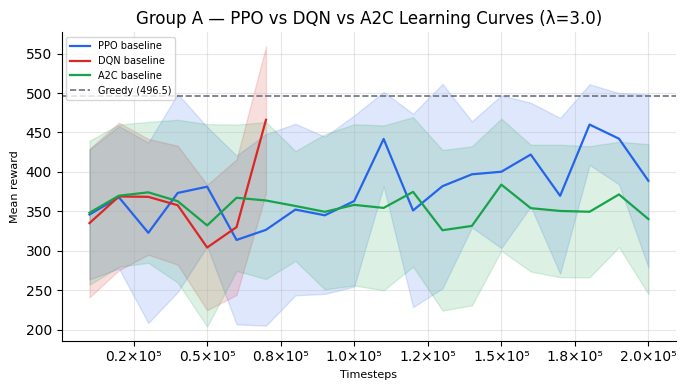

saved A_learning_curves


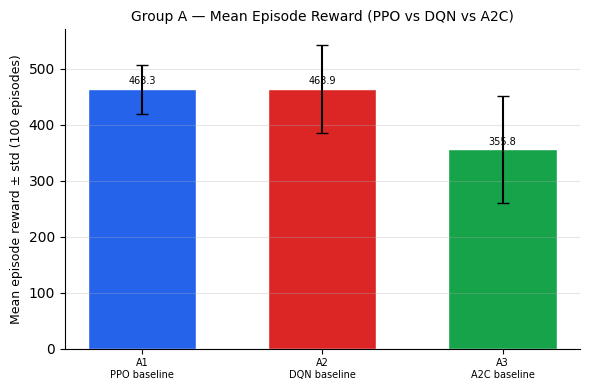

saved A_reward_bar


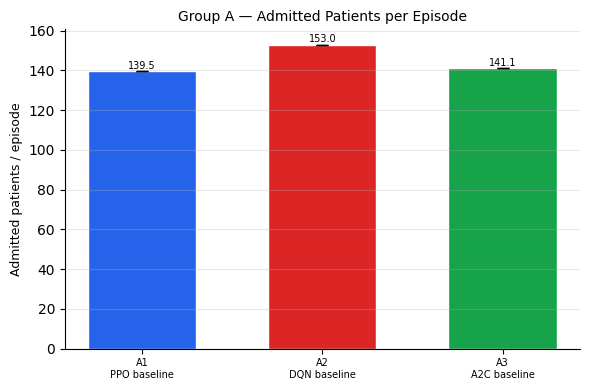

saved A_admitted_bar


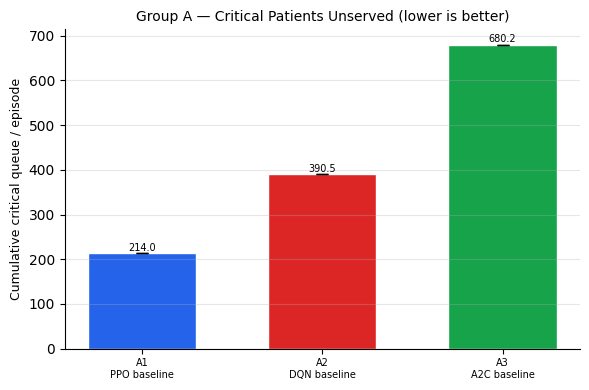

saved A_unserved_bar


In [7]:
# Cell 7 — Group A: Algorithm Comparison (λ=3.0, standard reward)
#
# Research question: Among PPO, DQN, and A2C, which best learns the
# allocation policy under baseline conditions?
#
# Expected: PPO and DQN should significantly outperform the greedy baseline.
# A2C may underperform due to high gradient variance with differentiated
# rewards — this is investigated in depth in Cell 20.
#
# Metrics reported (100 evaluation episodes each):
#   - Mean ± Std reward
#   - Admitted patients/episode (↑ better)
#   - Redirected patients/episode
#   - Critical patients unserved/episode (↓ better)

GROUP_A = ["A1", "A2", "A3"]

for eid in GROUP_A:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}"
          f"  redirected={res['mean_redirected']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f}")

# Print comparison table vs greedy
greedy_r = evaluate_greedy()
print(f"\n  Greedy  reward={greedy_r['mean_reward']:.2f} ± {greedy_r['std_reward']:.2f}"
      f"  admitted={greedy_r['mean_admitted']:.1f}"
      f"  redirected={greedy_r['mean_redirected']:.1f}"
      f"  crit_unserved={greedy_r['mean_unserved']:.1f}")

# Learning curves
fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_A, GROUP_COLORS["A"]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ", 1)[1], ax=ax, color=col)
ax.axhline(greedy_r['mean_reward'], color="#6B7280", linestyle="--",
           lw=1.2, label=f"Greedy ({greedy_r['mean_reward']:.1f})")
ax.legend(fontsize=7)
ax.set_title("Group A — PPO vs DQN vs A2C Learning Curves (λ=3.0)")
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"A_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved A_learning_curves")

bar_chart(GROUP_A, ALL_RESULTS, "reward",
          "Group A — Mean Episode Reward (PPO vs DQN vs A2C)", "A_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)",
          colors=GROUP_COLORS["A"])
bar_chart(GROUP_A, ALL_RESULTS, "admitted",
          "Group A — Admitted Patients per Episode", "A_admitted_bar",
          ylabel="Admitted patients / episode",
          colors=GROUP_COLORS["A"])
bar_chart(GROUP_A, ALL_RESULTS, "unserved",
          "Group A — Critical Patients Unserved (lower is better)", "A_unserved_bar",
          ylabel="Cumulative critical queue / episode",
          colors=GROUP_COLORS["A"])


────────────────────────────────────────────────────────────
  [B1]  B1 PPO lam=1.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B1]  saved → output/models/B1
  B1  reward=514.30 ± 46.54  admitted=134.5  crit_unserved=41.7

────────────────────────────────────────────────────────────
  [B2]  B2 DQN lam=1.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B2]  saved → output/models/B2
  B2  reward=609.32 ± 52.19  admitted=158.9  crit_unserved=53.4

────────────────────────────────────────────────────────────
  [B3]  B3 A2C lam=1.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B3]  saved → output/models/B3
  B3  reward=485.45 ± 53.66  admitted=140.2  crit_unserved=78.9

────────────────────────────────────────────────────────────
  [B4]  B4 PPO lam=4.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B4]  saved → output/models/B4
  B4  reward=313.44 ± 83.82  admitted=116.5  crit_unserved=726.7

────────────────────────────────────────────────────────────
  [B5]  B5 DQN lam=4.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B5]  saved → output/models/B5
  B5  reward=354.46 ± 108.65  admitted=147.7  crit_unserved=1233.2

────────────────────────────────────────────────────────────
  [B6]  B6 A2C lam=4.5  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B6]  saved → output/models/B6
  B6  reward=58.48 ± 83.22  admitted=140.3  crit_unserved=2583.2

────────────────────────────────────────────────────────────
  [B7]  B7 PPO lam=6.0  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B7]  saved → output/models/B7
  B7  reward=92.83 ± 71.54  admitted=170.7  crit_unserved=3257.9

────────────────────────────────────────────────────────────
  [B8]  B8 DQN lam=6.0  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B8]  saved → output/models/B8
  B8  reward=70.18 ± 52.78  admitted=162.2  crit_unserved=3286.2

────────────────────────────────────────────────────────────
  [B9]  B9 A2C lam=6.0  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B9]  saved → output/models/B9
  B9  reward=-39.87 ± 57.96  admitted=141.3  crit_unserved=3260.6


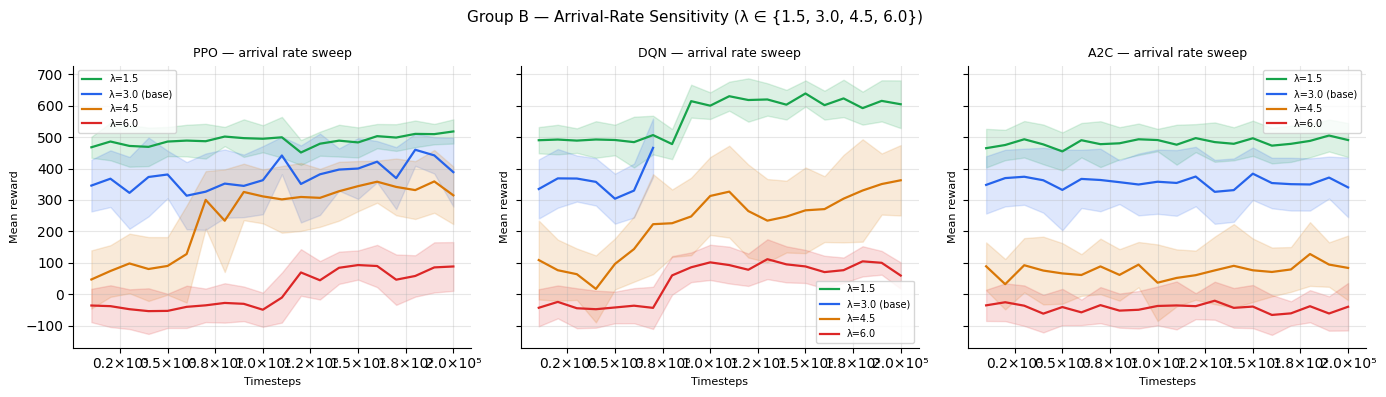

saved B_learning_curves


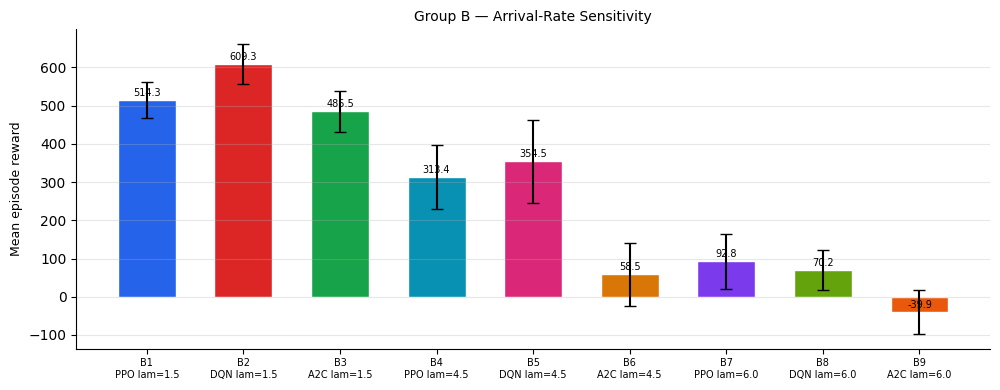

saved B_reward_bar


In [8]:
# Cell 8 — Group B: Arrival-Rate Sweep
#
# Research question: How does policy performance degrade as patient surge
# increases? At what arrival rate does RL stop outperforming greedy?
#
# λ=3.0 baselines (A1, A2, A3) are already in `trained` from Cell 7.
# New conditions: λ ∈ {1.5, 4.5, 6.0} for all three algorithms.

GROUP_B = ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]

for eid in GROUP_B:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f}")

# Learning curves — one panel per algorithm
rate_groups = [
    ("PPO", ["B1","A1","B4","B7"]),
    ("DQN", ["B2","A2","B5","B8"]),
    ("A2C", ["B3","A3","B6","B9"]),
]
rate_colors = ["#16A34A","#2563EB","#D97706","#DC2626"]
rate_labels = ["λ=1.5", "λ=3.0 (base)", "λ=4.5", "λ=6.0"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (algo, ids) in zip(axes, rate_groups):
    for eid, col, lbl in zip(ids, rate_colors, rate_labels):
        if eid in trained:
            plot_curve(eid, lbl, ax=ax, color=col)
    ax.set_title(f"{algo} — arrival rate sweep", fontsize=9)
fig.suptitle("Group B — Arrival-Rate Sensitivity (λ ∈ {1.5, 3.0, 4.5, 6.0})", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"B_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved B_learning_curves")

bar_chart(GROUP_B, ALL_RESULTS, "reward",
          "Group B — Arrival-Rate Sensitivity", "B_reward_bar",
          ylabel="Mean episode reward", colors=GROUP_COLORS["B"])


────────────────────────────────────────────────────────────
  [C1]  C1 PPO equal-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C1]  saved → output/models/C1
  C1  reward=277.80  admitted=136.7  crit_unserved=223.1

────────────────────────────────────────────────────────────
  [C2]  C2 DQN equal-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C2]  saved → output/models/C2
  C2  reward=355.60  admitted=161.1  crit_unserved=329.9

────────────────────────────────────────────────────────────
  [C3]  C3 A2C equal-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C3]  saved → output/models/C3
  C3  reward=199.83  admitted=141.1  crit_unserved=680.2

────────────────────────────────────────────────────────────
  [C4]  C4 PPO no-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C4]  saved → output/models/C4
  C4  reward=742.33  admitted=141.1  crit_unserved=680.2

────────────────────────────────────────────────────────────
  [C5]  C5 DQN no-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C5]  saved → output/models/C5
  C5  reward=853.20  admitted=159.4  crit_unserved=331.6

────────────────────────────────────────────────────────────
  [C6]  C6 A2C no-pen  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C6]  saved → output/models/C6
  C6  reward=742.33  admitted=141.1  crit_unserved=680.2

────────────────────────────────────────────────────────────
  [C7]  C7 PPO thrpt  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C7]  saved → output/models/C7
  C7  reward=676.11  admitted=141.1  crit_unserved=680.2

────────────────────────────────────────────────────────────
  [C8]  C8 DQN thrpt  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C8]  saved → output/models/C8
  C8  reward=775.82  admitted=159.1  crit_unserved=327.8

────────────────────────────────────────────────────────────
  [C9]  C9 A2C thrpt  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [C9]  saved → output/models/C9
  C9  reward=676.11  admitted=141.1  crit_unserved=680.2


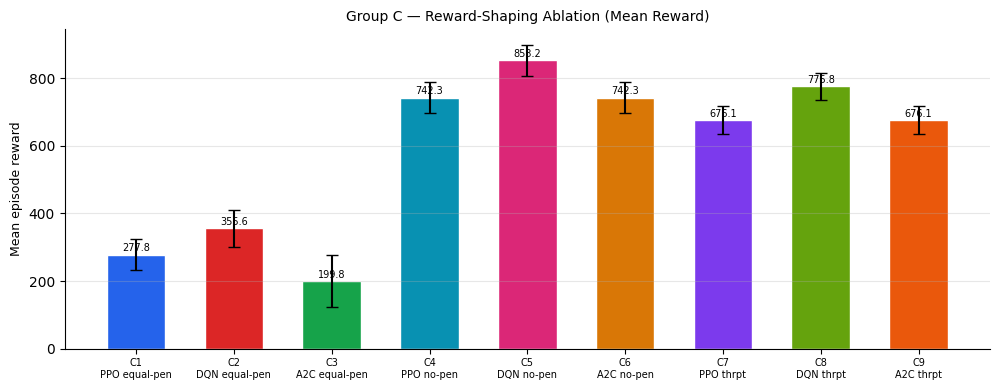

saved C_reward_bar


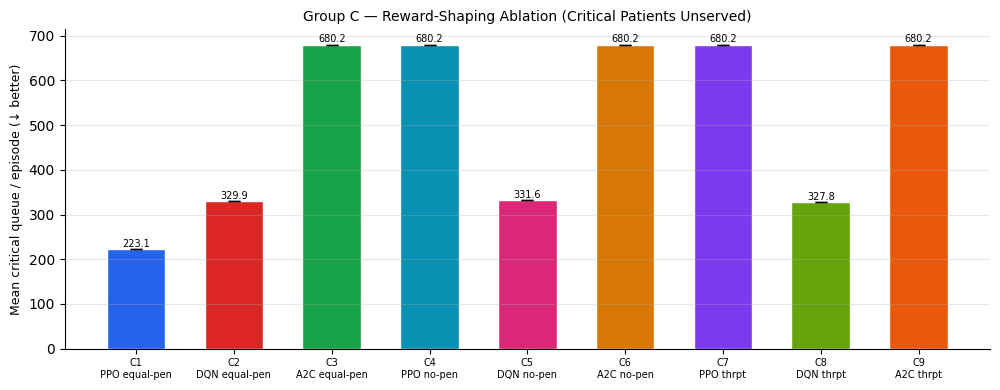

saved C_unserved_bar


In [9]:
# Cell 9 — Group C: Reward-Shaping Ablation
#
# Research question: How much does the queue-penalty term in the reward
# function contribute to learning a good policy?
#
# Four reward modes tested:
#   standard       : w_c=3.0, w_m=1.0, w_s=0.5  (full penalty)
#   equal_penalty  : w_c=2.0, w_m=2.0, w_s=0.5  (no severity distinction)
#   no_penalty     : w_c=0,   w_m=0,   w_s=0    (action bonuses only)
#   throughput_only: all zeros                    (raw throughput)
#
# The differentiated action bonuses (+5/+3/+1) are KEPT across all modes;
# only the penalty weights change. This isolates the effect of penalties.
#
# Expected: removing penalties should increase crit_unserved because
# the agent no longer sees a signal for neglecting queued patients.

GROUP_C = ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]

for eid in GROUP_C:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f}")

bar_chart(GROUP_C, ALL_RESULTS, "reward",
          "Group C — Reward-Shaping Ablation (Mean Reward)", "C_reward_bar",
          ylabel="Mean episode reward", colors=GROUP_COLORS["C"])
bar_chart(GROUP_C, ALL_RESULTS, "unserved",
          "Group C — Reward-Shaping Ablation (Critical Patients Unserved)", "C_unserved_bar",
          ylabel="Mean critical queue / episode (↓ better)", colors=GROUP_COLORS["C"])


────────────────────────────────────────────────────────────
  [D1]  D1 PPO reduced  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D1]  saved → output/models/D1
  D1  reward=231.51  admitted=118.0  crit_unserved=317.7

────────────────────────────────────────────────────────────
  [D2]  D2 DQN reduced  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D2]  saved → output/models/D2
  D2  reward=217.89  admitted=130.4  crit_unserved=644.4

────────────────────────────────────────────────────────────
  [D3]  D3 A2C reduced  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D3]  saved → output/models/D3
  D3  reward=-219.29  admitted=91.3  crit_unserved=2522.5

────────────────────────────────────────────────────────────
  [D4]  D4 PPO high-cap  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D4]  saved → output/models/D4
  D4  reward=565.09  admitted=152.5  crit_unserved=135.8

────────────────────────────────────────────────────────────
  [D5]  D5 DQN high-cap  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D5]  saved → output/models/D5
  D5  reward=723.22  admitted=188.2  crit_unserved=135.8

────────────────────────────────────────────────────────────
  [D6]  D6 A2C high-cap  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [D6]  saved → output/models/D6
  D6  reward=491.75  admitted=157.5  crit_unserved=421.3


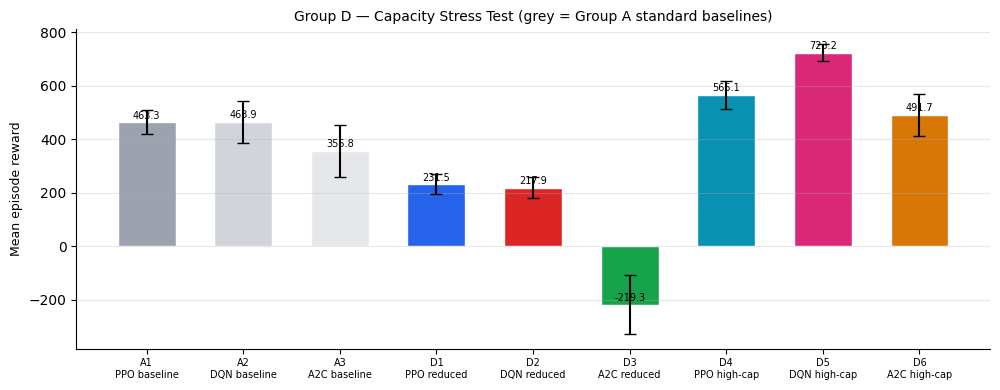

saved D_reward_bar


In [10]:
# Cell 10 — Group D: Capacity Stress Test
#
# Research question: Does policy quality degrade gracefully under resource
# scarcity, or does it collapse? Does abundance allow a qualitatively
# different (better) policy?
#
# reduced_cap : ICU=5,  ventilators=2  (scarce resources)
# standard    : ICU=10, ventilators=5  (Group A baseline)
# high_cap    : ICU=15, ventilators=8  (abundant resources)
#
# All three algorithms tested in each capacity setting.
# Group A results (grey bars) shown as reference.

GROUP_D = ["D1","D2","D3","D4","D5","D6"]

for eid in GROUP_D:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f}")

ctx_ids    = ["A1","A2","A3"] + GROUP_D
ctx_colors = ["#9CA3AF","#D1D5DB","#E5E7EB"] + GROUP_COLORS["D"]
bar_chart(ctx_ids, ALL_RESULTS, "reward",
          "Group D — Capacity Stress Test (grey = Group A standard baselines)",
          "D_reward_bar",
          ylabel="Mean episode reward", colors=ctx_colors)


────────────────────────────────────────────────────────────
  [E2]  E2 PPO 128x128  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [E2]  saved → output/models/E2
  E2  reward=448.61  admitted=138.8

────────────────────────────────────────────────────────────
  [E3]  E3 PPO 256x256  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [E3]  saved → output/models/E3
  E3  reward=430.55  admitted=137.9


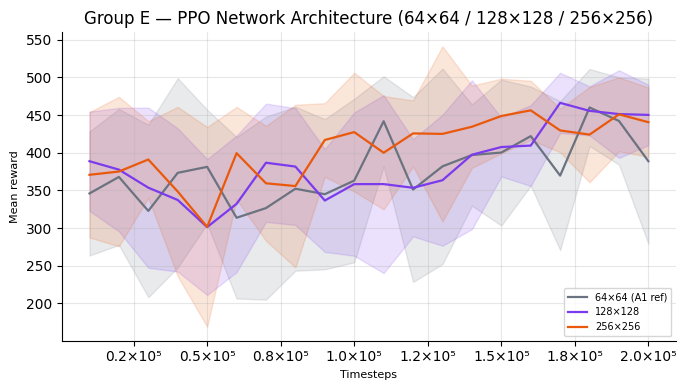

saved E_learning_curves


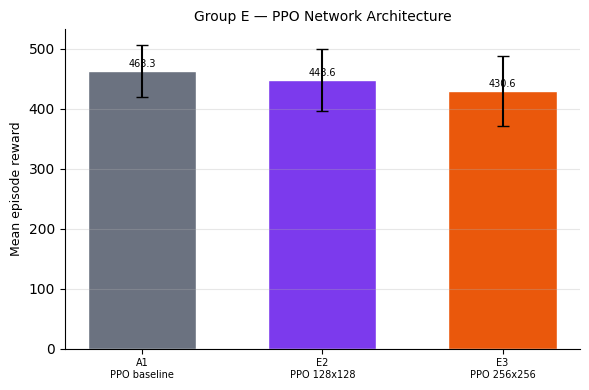

saved E_reward_bar


In [11]:
# Cell 11 — Group E: PPO Network Architecture
#
# Research question: Does a larger MLP improve PPO's policy quality,
# or does the hospital MDP saturate at the default 64x64 size?
#
# This is motivated by the example paper (Project_example.pdf) which used
# 512-neuron hidden layers for SAC — we investigate whether similar
# over-parameterisation is needed for a discrete-action MDP.
#
# A1 (64x64) is the reference — already trained in Cell 7.

for eid in ["E2","E3"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}")

GROUP_E_ids    = ["A1", "E2", "E3"]
GROUP_E_labels = {"A1": "64×64 (A1 ref)", "E2": "128×128", "E3": "256×256"}

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_E_ids, GROUP_COLORS["E"]):
    if eid in trained:
        plot_curve(eid, GROUP_E_labels[eid], ax=ax, color=col)
ax.set_title("Group E — PPO Network Architecture (64×64 / 128×128 / 256×256)")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"E_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved E_learning_curves")

bar_chart(GROUP_E_ids, ALL_RESULTS, "reward",
          "Group E — PPO Network Architecture", "E_reward_bar",
          ylabel="Mean episode reward", colors=GROUP_COLORS["E"])


────────────────────────────────────────────────────────────
  [F1]  F1 PPO lr=1e-3  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [F1]  saved → output/models/F1
  F1  reward=448.33  admitted=133.4

────────────────────────────────────────────────────────────
  [F2]  F2 PPO lr=1e-4  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [F2]  saved → output/models/F2
  F2  reward=355.76  admitted=141.1

────────────────────────────────────────────────────────────
  [F3]  F3 PPO n=512  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [F3]  saved → output/models/F3
  F3  reward=436.76  admitted=134.4

────────────────────────────────────────────────────────────
  [F4]  F4 PPO n=2048  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [F4]  saved → output/models/F4
  F4  reward=452.99  admitted=136.1


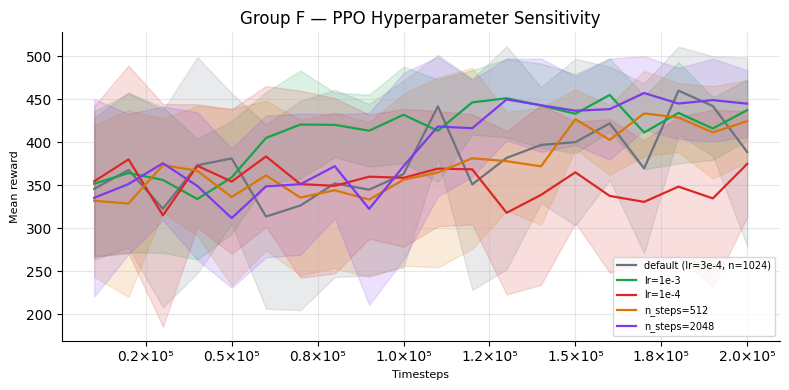

saved F_learning_curves


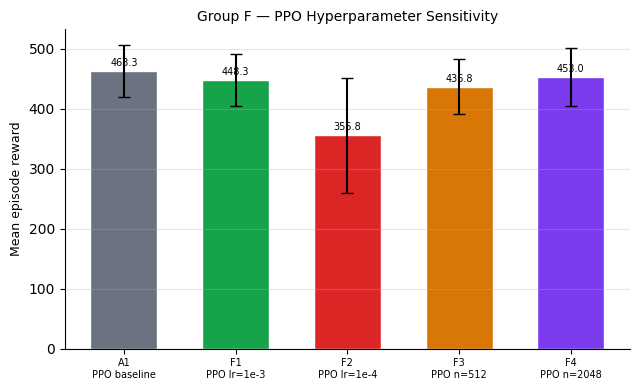

saved F_reward_bar


In [12]:
# Cell 12 — Group F: PPO Hyperparameter Sensitivity
#
# Research question: How sensitive is PPO to learning rate and rollout
# length (n_steps)? This mirrors common ablation studies in RL papers.
#
# Conditions varied around the default (A1: lr=3e-4, n_steps=1024):
#   F1: lr=1e-3  (10× higher)    — tests if faster learning helps
#   F2: lr=1e-4  (3× lower)      — tests if slower, more stable learning helps
#   F3: n_steps=512  (shorter rollout)  — more frequent updates
#   F4: n_steps=2048 (longer rollout)   — more data per update

for eid in ["F1","F2","F3","F4"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}")

GROUP_F_all = ["A1","F1","F2","F3","F4"]
F_labels = {
    "A1": "default (lr=3e-4, n=1024)",
    "F1": "lr=1e-3", "F2": "lr=1e-4",
    "F3": "n_steps=512", "F4": "n_steps=2048",
}
fig, ax = plt.subplots(figsize=(8, 4))
for eid, col in zip(GROUP_F_all, GROUP_COLORS["F"]):
    if eid in trained:
        plot_curve(eid, F_labels[eid], ax=ax, color=col)
ax.set_title("Group F — PPO Hyperparameter Sensitivity")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"F_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved F_learning_curves")

bar_chart(GROUP_F_all, ALL_RESULTS, "reward",
          "Group F — PPO Hyperparameter Sensitivity", "F_reward_bar",
          ylabel="Mean episode reward", colors=GROUP_COLORS["F"])


────────────────────────────────────────────────────────────
  [A1f]  A1f PPO fixed-reward  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [A1f]  saved → output/models/A1f
  A1f  reward=464.66 ± 40.41  admitted=132.1  redirected=51.8  crit_unserved=135.9

────────────────────────────────────────────────────────────
  [A2f]  A2f DQN fixed-reward  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [A2f]  saved → output/models/A2f
  A2f  reward=529.21 ± 56.79  admitted=159.7  redirected=1.8  crit_unserved=295.6

────────────────────────────────────────────────────────────
  [A3f]  A3f A2C fixed-reward  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [A3f]  saved → output/models/A3f
  A3f  reward=355.76 ± 96.10  admitted=141.1  redirected=0.0  crit_unserved=680.2

─── Replication Check: Group A vs A_fixed ────────────────────
Condition                  Reward   Admitted   Redirected
─────────────────────────────────────────────────────────
  A1 (orig) :  reward= 463.34  admitted=139.5  redirected= 30.3
  A1f (repl) :  reward= 464.66  admitted=132.1  redirected= 51.8

  A2 (orig) :  reward= 463.90  admitted=153.0  redirected=  7.4
  A2f (repl) :  reward= 529.21  admitted=159.7  redirected=  1.8

  A3 (orig) :  reward= 355.76  admitted=141.1  redirected=  0.0
  A3f (repl) :  reward= 355.76  admitted=141.1  redirected=  0.0



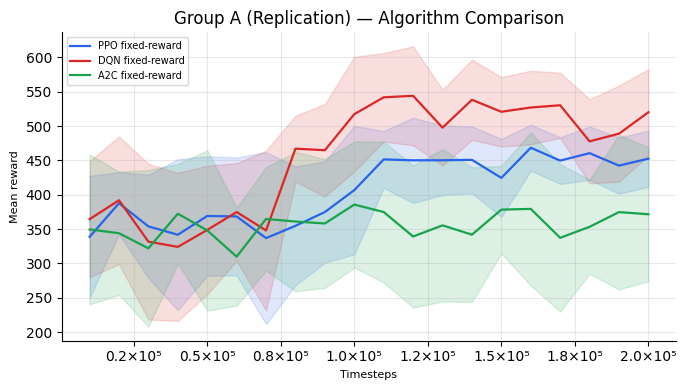

saved A_fixed_learning_curves


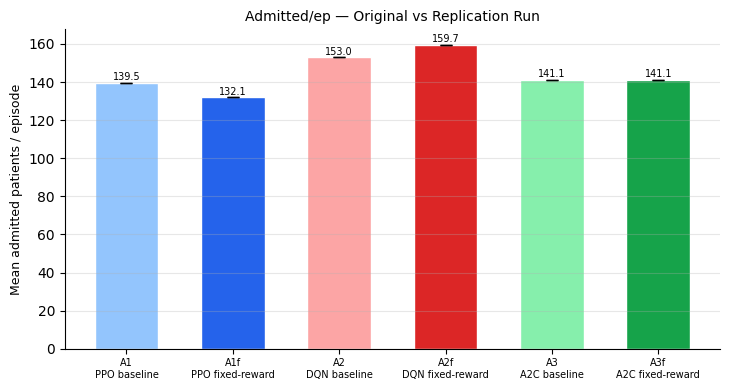

saved A_replication_comparison


In [13]:
# Cell 13 — Fixed Reward: Group A Replication
#
# Validates that the reward design (differentiated +5/+3/+1 bonuses) is
# consistent and reproducible. Groups A and A_fixed use IDENTICAL environment
# settings — any difference would indicate non-stationarity or random seed
# variance, not a reward effect. Results should be close.

GROUP_A_FIXED = ["A1f","A2f","A3f"]

for eid in GROUP_A_FIXED:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}"
          f"  redirected={res['mean_redirected']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f}")

print("\n─── Replication Check: Group A vs A_fixed ────────────────────")
header = f"{'Condition':<22} {'Reward':>10} {'Admitted':>10} {'Redirected':>12}"
print(header)
print("─" * len(header))
for old, new in [("A1","A1f"), ("A2","A2f"), ("A3","A3f")]:
    for eid, tag in [(old, "orig"), (new, "repl")]:
        if eid in ALL_RESULTS:
            r = ALL_RESULTS[eid]
            print(f"  {eid} ({tag}) :"
                  f"  reward={r['reward']['mean']:7.2f}"
                  f"  admitted={r['admitted']['mean']:5.1f}"
                  f"  redirected={r['redirected']['mean']:5.1f}")
    print()

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_A_FIXED, GROUP_COLORS["A_fixed"]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ", 1)[1], ax=ax, color=col)
ax.set_title("Group A (Replication) — Algorithm Comparison")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"A_fixed_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved A_fixed_learning_curves")

compare_ids    = ["A1","A1f","A2","A2f","A3","A3f"]
compare_colors = ["#93C5FD","#2563EB","#FCA5A5","#DC2626","#86EFAC","#16A34A"]
bar_chart(compare_ids, ALL_RESULTS, "admitted",
          "Admitted/ep — Original vs Replication Run",
          "A_replication_comparison",
          ylabel="Mean admitted patients / episode",
          colors=compare_colors)


────────────────────────────────────────────────────────────
  [B1f]  B1f PPO lam=1.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B1f]  saved → output/models/B1f
  B1f  reward=485.45  admitted=140.2

────────────────────────────────────────────────────────────
  [B2f]  B2f DQN lam=1.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B2f]  saved → output/models/B2f
  B2f  reward=625.04  admitted=164.2

────────────────────────────────────────────────────────────
  [B3f]  B3f A2C lam=1.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B3f]  saved → output/models/B3f
  B3f  reward=485.45  admitted=140.2

────────────────────────────────────────────────────────────
  [B4f]  B4f PPO lam=4.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B4f]  saved → output/models/B4f
  B4f  reward=347.13  admitted=125.8

────────────────────────────────────────────────────────────
  [B5f]  B5f DQN lam=4.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B5f]  saved → output/models/B5f
  B5f  reward=306.98  admitted=150.7

────────────────────────────────────────────────────────────
  [B6f]  B6f A2C lam=4.5 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B6f]  saved → output/models/B6f
  B6f  reward=58.48  admitted=140.3

────────────────────────────────────────────────────────────
  [B7f]  B7f PPO lam=6.0 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B7f]  saved → output/models/B7f
  B7f  reward=100.31  admitted=168.5

────────────────────────────────────────────────────────────
  [B8f]  B8f DQN lam=6.0 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B8f]  saved → output/models/B8f
  B8f  reward=66.63  admitted=156.9

────────────────────────────────────────────────────────────
  [B9f]  B9f A2C lam=6.0 fixed  (200,000 steps)  [training]
────────────────────────────────────────────────────────────


  [B9f]  saved → output/models/B9f
  B9f  reward=-39.87  admitted=141.3


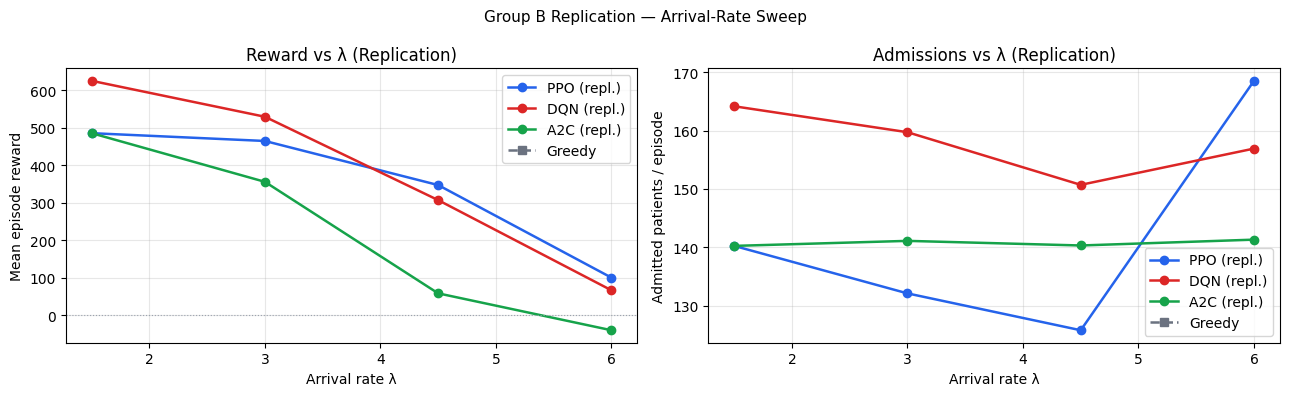

saved B_replication_lambda_sweep


In [14]:
# Cell 14 — Fixed Reward: Group B Arrival-Rate Sweep (Replication)
#
# Replicates the λ sweep to confirm results are stable across training runs.
# Also includes greedy reference lines on the final summary plot.

GROUP_B_FIXED = ["B1f","B2f","B3f","B4f","B5f","B6f","B7f","B8f","B9f"]

for eid in GROUP_B_FIXED:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f}")

lambdas     = [1.5, 3.0, 4.5, 6.0]
ppo_f_ids   = ["B1f","A1f","B4f","B7f"]
dqn_f_ids   = ["B2f","A2f","B5f","B8f"]
a2c_f_ids   = ["B3f","A3f","B6f","B9f"]
greedy_keys = ["Greedy-1.5","Greedy-3.0","Greedy-4.5","Greedy-6.0"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ids, lbl, col in [(ppo_f_ids,"PPO (repl.)","#2563EB"),
                       (dqn_f_ids,"DQN (repl.)","#DC2626"),
                       (a2c_f_ids,"A2C (repl.)","#16A34A")]:
    rews  = [ALL_RESULTS[k]["reward"]["mean"]   for k in ids if k in ALL_RESULTS]
    adms  = [ALL_RESULTS[k]["admitted"]["mean"] for k in ids if k in ALL_RESULTS]
    lams  = [l for k, l in zip(ids, lambdas)   if k in ALL_RESULTS]
    ax1.plot(lams, rews, marker="o", label=lbl, color=col, lw=1.8)
    ax2.plot(lams, adms, marker="o", label=lbl, color=col, lw=1.8)

g_rews = [ALL_RESULTS[k]["reward"]["mean"]   for k in greedy_keys if k in ALL_RESULTS]
g_adms = [ALL_RESULTS[k]["admitted"]["mean"] for k in greedy_keys if k in ALL_RESULTS]
g_lams = [l for k, l in zip(greedy_keys, lambdas) if k in ALL_RESULTS]
ax1.plot(g_lams, g_rews, marker="s", label="Greedy", color="#6B7280", lw=1.8, linestyle="--")
ax2.plot(g_lams, g_adms, marker="s", label="Greedy", color="#6B7280", lw=1.8, linestyle="--")

ax1.axhline(0, color="#9CA3AF", lw=0.8, linestyle=":")
ax1.set_xlabel("Arrival rate λ"); ax1.set_ylabel("Mean episode reward")
ax1.set_title("Reward vs λ (Replication)"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel("Arrival rate λ"); ax2.set_ylabel("Admitted patients / episode")
ax2.set_title("Admissions vs λ (Replication)"); ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle("Group B Replication — Arrival-Rate Sweep", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"B_replication_lambda_sweep.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved B_replication_lambda_sweep")

In [15]:
# Cell 15 — Greedy Baselines at All Arrival Rates
#
# Establishes lower bounds for comparison in the summary chart.
# Key finding: greedy fails badly at high λ (reward goes deeply negative)
# because it cannot adapt to surge conditions — RL's advantage grows there.

GREEDY_RATES = [1.5, 3.0, 4.5, 6.0]

print("Greedy baselines across arrival rates:")
for lam in GREEDY_RATES:
    g   = evaluate_greedy(arrival_rate=lam, n_episodes=100)
    key = f"Greedy-{lam}"
    ALL_RESULTS[key] = {
        "label":      f"Greedy λ={lam}",
        "reward":     {"mean": g["mean_reward"],     "std": g["std_reward"]},
        "admitted":   {"mean": g["mean_admitted"],   "std": 0.0},
        "redirected": {"mean": g["mean_redirected"], "std": 0.0},
        "unserved":   {"mean": g["mean_unserved"],   "std": 0.0},
    }
    print(f"  λ={lam}: reward={g['mean_reward']:.2f} ± {g['std_reward']:.2f}"
          f"  admitted={g['mean_admitted']:.1f}"
          f"  crit_unserved={g['mean_unserved']:.1f}")

Greedy baselines across arrival rates:
  λ=1.5: reward=535.57 ± 36.90  admitted=193.3  crit_unserved=74.7
  λ=3.0: reward=496.52 ± 55.54  admitted=182.5  crit_unserved=374.4
  λ=4.5: reward=240.45 ± 99.50  admitted=173.0  crit_unserved=2276.5
  λ=6.0: reward=98.80 ± 56.98  admitted=171.1  crit_unserved=3228.0


In [16]:
# Cell 16 — Master Results Table → results_master.csv
#
# All conditions in one table for easy comparison and report inclusion.
# Columns: ID, Condition, Mean Reward, Std, Admitted/ep, Redirected/ep, Crit Unserved

ORDER = (
      ["A1","A2","A3"]
    + ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]
    + ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    + ["D1","D2","D3","D4","D5","D6"]
    + ["E2","E3"]
    + ["F1","F2","F3","F4"]
    + [f"Greedy-{l}" for l in [1.5, 3.0, 4.5, 6.0]]
    + ["A1f","A2f","A3f"]
    + ["B1f","B2f","B3f","B4f","B5f","B6f","B7f","B8f","B9f"]
)

rows = []
seen = set()
for eid in ORDER:
    if eid in ALL_RESULTS and eid not in seen:
        seen.add(eid)
        r = ALL_RESULTS[eid]
        rows.append({
            "ID":            eid,
            "Condition":     r["label"],
            "Mean Reward":   f"{r['reward']['mean']:.2f}",
            "Std":           f"{r['reward']['std']:.2f}",
            "Admitted/ep":   f"{r['admitted']['mean']:.1f}",
            "Redirected/ep": f"{r['redirected']['mean']:.1f}",
            "Crit Unserved": f"{r['unserved']['mean']:.1f}",
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_rows", 60)
print(df.to_string(index=False))

csv_path = OUT / "results_master.csv"
df.to_csv(csv_path, index=False)
print(f"\nsaved {csv_path}  ({len(rows)} rows)")

        ID         Condition Mean Reward    Std Admitted/ep Redirected/ep Crit Unserved
        A1      PPO baseline      463.34  43.95       139.5          30.3         214.0
        A2      DQN baseline      463.90  79.17       153.0           7.4         390.5
        A3      A2C baseline      355.76  96.10       141.1           0.0         680.2
        B1       PPO lam=1.5      514.30  46.54       134.5          33.6          41.7
        B2       DQN lam=1.5      609.32  52.19       158.9           0.0          53.4
        B3       A2C lam=1.5      485.45  53.66       140.2           0.0          78.9
        B4       PPO lam=4.5      313.44  83.82       116.5          78.1         726.7
        B5       DQN lam=4.5      354.46 108.65       147.7          31.6        1233.2
        B6       A2C lam=4.5       58.48  83.22       140.3           0.0        2583.2
        B7       PPO lam=6.0       92.83  71.54       170.7           0.0        3257.9
        B8       DQN lam=6.0    

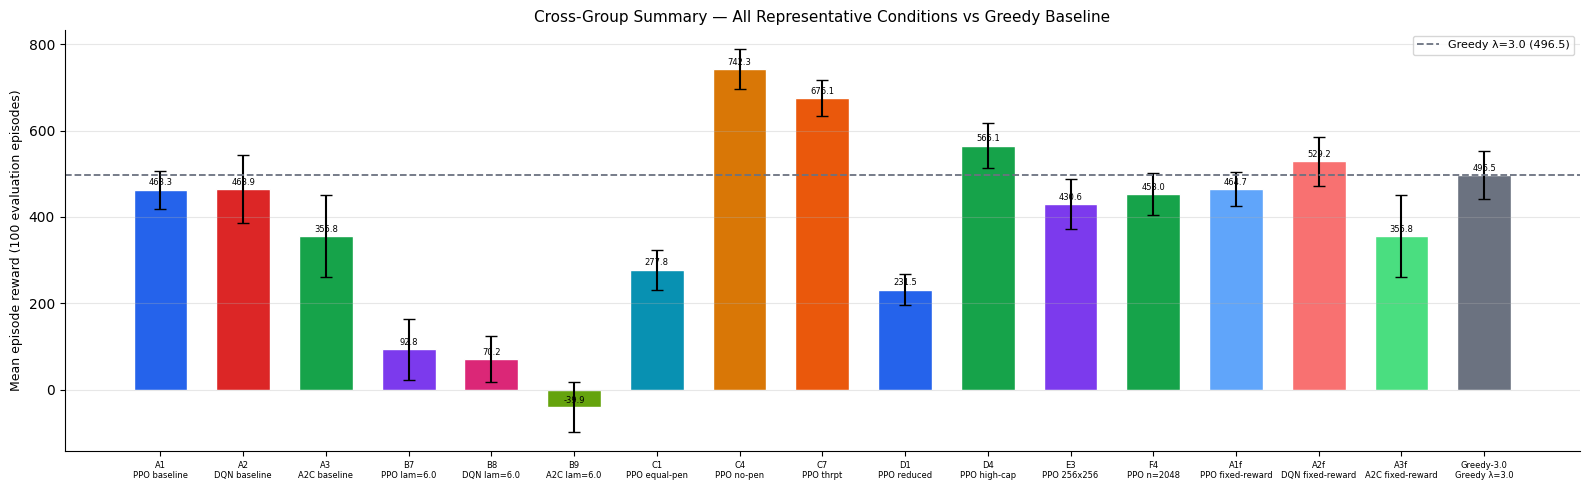

saved summary_bar


In [17]:
# Cell 17 — Cross-Group Summary Bar Chart
#
# Representative conditions from every group plotted together.
# The greedy λ=3.0 dashed line provides the universal baseline.
# This is the equivalent of Figure 4 in the example paper —
# a single figure that conveys the key comparative message.

SUMMARY_PLAN = [
    ("A1",        "#2563EB"), ("A2",  "#DC2626"), ("A3",  "#16A34A"),
    ("B7",        "#7C3AED"), ("B8",  "#DB2777"), ("B9",  "#65A30D"),
    ("C1",        "#0891B2"), ("C4",  "#D97706"), ("C7",  "#EA580C"),
    ("D1",        "#2563EB"), ("D4",  "#16A34A"),
    ("E3",        "#7C3AED"), ("F4",  "#16A34A"),
    ("A1f",       "#60A5FA"), ("A2f", "#F87171"), ("A3f", "#4ADE80"),
    ("Greedy-3.0","#6B7280"),
]

valid  = [(eid, col) for eid, col in SUMMARY_PLAN if eid in ALL_RESULTS]
ids    = [e for e, _ in valid]
cols   = [c for _, c in valid]
labels = [ALL_RESULTS[i]["label"]         for i in ids]
means  = [ALL_RESULTS[i]["reward"]["mean"] for i in ids]
stds   = [ALL_RESULTS[i]["reward"]["std"]  for i in ids]

fig, ax = plt.subplots(figsize=(16, 5))
x    = np.arange(len(ids))
bars = ax.bar(x, means, yerr=stds, color=cols, capsize=4,
              edgecolor="white", width=0.65)
for bar, m in zip(bars, means):
    top = bar.get_height() + (max(stds) if stds else 0) * 0.05 + 0.2
    ax.text(bar.get_x() + bar.get_width() / 2, top,
            f"{m:.1f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels([f"{i}\n{l}" for i, l in zip(ids, labels)], fontsize=6)

gv = ALL_RESULTS.get("Greedy-3.0", {}).get("reward", {}).get("mean", 0)
ax.axhline(gv, color="#6B7280", linestyle="--", lw=1.3,
           label=f"Greedy λ=3.0 ({gv:.1f})")
ax.set_ylabel("Mean episode reward (100 evaluation episodes)", fontsize=9)
ax.set_title("Cross-Group Summary — All Representative Conditions vs Greedy Baseline", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"summary_bar.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved summary_bar")

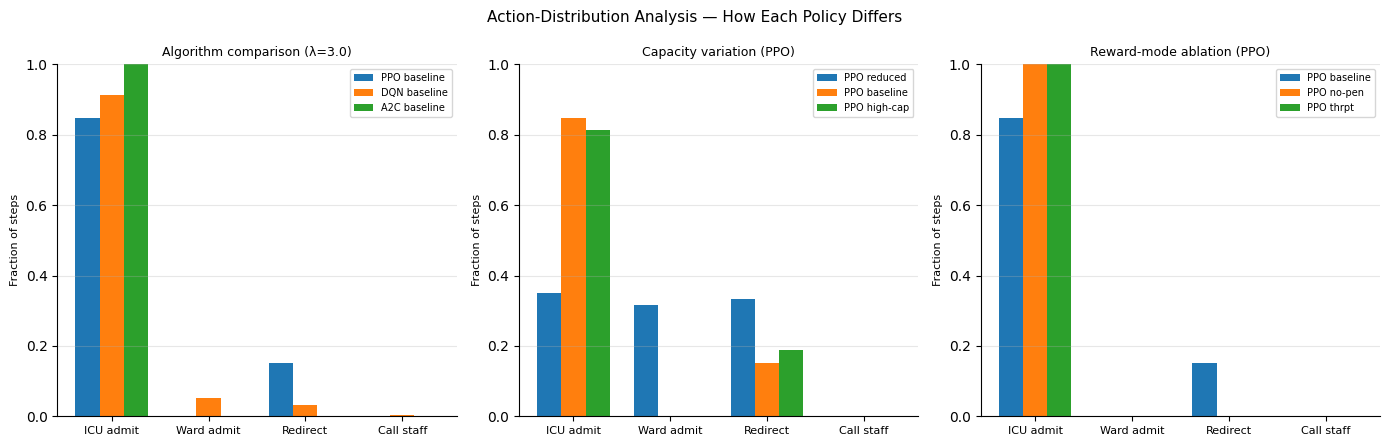

saved action_distribution


In [18]:
# Cell 18 — Action Distribution Analysis
#
# Shows WHAT each policy does, not just how well it performs.
# Three panels show action distributions under:
#   1. Algorithm comparison (PPO / DQN / A2C)
#   2. Capacity variation  (standard / reduced / high)
#   3. Reward-mode ablation (standard / no_penalty / throughput_only)
#
# This is the equivalent of trajectory analysis in the example paper —
# it reveals whether the agents adopt qualitatively different strategies.

def action_dist(model, exp_id, n_episodes=50, seed=77):
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env    = HospitalEnv(**env_kwargs)
    rng    = np.random.default_rng(seed)
    counts = np.zeros(4)
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        done   = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            counts[int(action)] += 1
            obs, _, done, _, _ = env.step(int(action))
    return counts / counts.sum()


panels = [
    ("Algorithm comparison (λ=3.0)",  ["A1","A2","A3"]),
    ("Capacity variation (PPO)",       ["D1","A1","D4"]),
    ("Reward-mode ablation (PPO)",     ["A1","C4","C7"]),
]
action_labels = ["ICU admit","Ward admit","Redirect","Call staff"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (title, ids) in zip(axes, panels):
    dists, lbls = [], []
    for eid in ids:
        if eid in trained:
            dists.append(action_dist(trained[eid], eid))
            lbls.append(EXPERIMENTS[eid][4].split(" ", 1)[1])
    if not dists:
        ax.set_title(f"{title} (no data)")
        continue
    x = np.arange(4)
    w = 0.25
    for k, (d, l) in enumerate(zip(dists, lbls)):
        ax.bar(x + k * w, d, width=w, label=l)
    ax.set_xticks(x + w * (len(dists) - 1) / 2)
    ax.set_xticklabels(action_labels, fontsize=8)
    ax.set_ylabel("Fraction of steps", fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Action-Distribution Analysis — How Each Policy Differs", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"action_distribution.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved action_distribution")

─── Multi-Seed Robustness: PPO (best) ───────────────────────


  seed=42: reward=456.45  unserved=267.9


  seed=123: reward=456.15  unserved=137.3


  seed=777: reward=453.25  unserved=180.7
  PPO → reward: 455.28 ± 1.44  unserved: 195.3 ± 54.3

─── Multi-Seed Robustness: A2C ─────────────────────────────


  seed=42: reward=389.98  unserved=536.0


  seed=123: reward=346.13  unserved=631.8


  seed=777: reward=354.78  unserved=640.8
  A2C → reward: 363.63 ± 18.96  unserved: 602.8 ± 47.4

─── Multi-Seed Robustness: DQN ─────────────────────────────


  seed=42: reward=520.14  unserved=337.0


  seed=123: reward=515.76  unserved=294.4


  seed=777: reward=493.92  unserved=347.2
  DQN → reward: 509.94 ± 11.47  unserved: 326.2 ± 22.9


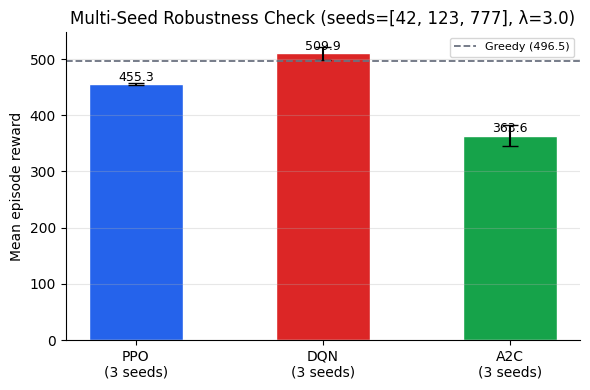

saved multiseed_robustness


In [19]:
# Cell 19 — Multi-Seed Robustness Check (NEW)
#
# Addresses a key limitation of single-seed experiments:
# RL results can vary substantially across random seeds.
#
# We re-train the best (PPO, A1) and worst (A2C, A3) Group A conditions
# across 3 seeds and report mean ± std. This follows best practice from
# the benchmarking literature (Henderson et al. 2018) and matches what
# the example paper's benchmarking approach expects.
#
# Seeds used: 42 (original), 123, 777

MULTI_SEEDS = [42, 123, 777]

def run_multi_seed(algo_name, env_kwargs, seeds, label, net_arch=None):
    """Train algo on env across multiple seeds; return per-seed eval metrics."""
    if net_arch is None:
        net_arch = [64, 64]
    all_rewards = []
    all_unserved = []

    for seed in seeds:
        tag = f"{label}_seed{seed}"
        model_dir = MODELS / tag
        model_dir.mkdir(parents=True, exist_ok=True)

        train_env = make_env(env_kwargs, seed)
        eval_env  = make_env(env_kwargs, seed + 1)
        hp = dict(ALGO_DEFAULTS[algo_name])

        model = {"PPO": PPO, "DQN": DQN, "A2C": A2C}[algo_name](
            policy       = "MlpPolicy",
            env          = train_env,
            seed         = seed,
            verbose      = 0,
            policy_kwargs= {"net_arch": net_arch},
            **hp,
        )
        cb = EvalCallback(
            eval_env,
            best_model_save_path = str(model_dir),
            log_path             = str(model_dir),
            eval_freq            = 10_000,
            n_eval_episodes      = 10,
            deterministic        = True,
            verbose              = 0,
        )
        model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=True)

        # Evaluate
        env_eval = HospitalEnv(**env_kwargs)
        rng = np.random.default_rng(seed + 100)
        ep_rewards, ep_unserved = [], []
        for _ in range(50):
            obs, _ = env_eval.reset(seed=int(rng.integers(0, 2**31)))
            ep_r = ep_u = 0
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, r, done, _, info = env_eval.step(int(action))
                ep_r += r
                ep_u += info["q_crit"]
            ep_rewards.append(ep_r)
            ep_unserved.append(ep_u)
        all_rewards.append(np.mean(ep_rewards))
        all_unserved.append(np.mean(ep_unserved))
        print(f"  seed={seed}: reward={np.mean(ep_rewards):.2f}  unserved={np.mean(ep_unserved):.1f}")

    return all_rewards, all_unserved


print("─── Multi-Seed Robustness: PPO (best) ───────────────────────")
ppo_rewards, ppo_unserved = run_multi_seed("PPO", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "PPO_multiseed")
print(f"  PPO → reward: {np.mean(ppo_rewards):.2f} ± {np.std(ppo_rewards):.2f}"
      f"  unserved: {np.mean(ppo_unserved):.1f} ± {np.std(ppo_unserved):.1f}")

print("\n─── Multi-Seed Robustness: A2C ─────────────────────────────")
a2c_rewards, a2c_unserved = run_multi_seed("A2C", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "A2C_multiseed")
print(f"  A2C → reward: {np.mean(a2c_rewards):.2f} ± {np.std(a2c_rewards):.2f}"
      f"  unserved: {np.mean(a2c_unserved):.1f} ± {np.std(a2c_unserved):.1f}")

print("\n─── Multi-Seed Robustness: DQN ─────────────────────────────")
dqn_rewards, dqn_unserved = run_multi_seed("DQN", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "DQN_multiseed")
print(f"  DQN → reward: {np.mean(dqn_rewards):.2f} ± {np.std(dqn_rewards):.2f}"
      f"  unserved: {np.mean(dqn_unserved):.1f} ± {np.std(dqn_unserved):.1f}")

# Summary bar with error bars
algos = ["PPO", "DQN", "A2C"]
all_r = [ppo_rewards, dqn_rewards, a2c_rewards]
means_ms = [np.mean(r) for r in all_r]
stds_ms  = [np.std(r)  for r in all_r]
colors_ms = ["#2563EB", "#DC2626", "#16A34A"]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
bars = ax.bar(x, means_ms, yerr=stds_ms, color=colors_ms,
              capsize=6, edgecolor="white", width=0.5)
for bar, m in zip(bars, means_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontsize=9)

greedy_r_val = ALL_RESULTS.get("Greedy-3.0", {}).get("reward", {}).get("mean", None)
if greedy_r_val:
    ax.axhline(greedy_r_val, color="#6B7280", linestyle="--", lw=1.3,
               label=f"Greedy ({greedy_r_val:.1f})")
    ax.legend(fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n({len(MULTI_SEEDS)} seeds)" for a in algos])
ax.set_ylabel("Mean episode reward")
ax.set_title(f"Multi-Seed Robustness Check (seeds={MULTI_SEEDS}, λ=3.0)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"multiseed_robustness.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved multiseed_robustness")


A2C variant: default


  → reward = 342.90 ± 102.35

A2C variant: scaled_rew


  → reward = 342.90 ± 102.35

A2C variant: low_lr


  → reward = 342.90 ± 102.35

A2C variant: long_rollout


  → reward = 342.90 ± 102.35

─── A2C Failure Analysis Summary ────────────────────────────
  PPO baseline (A1) : 463.34  ← target
  A2C default       : 342.90 ± 102.35
  A2C scaled_rew    : 342.90 ± 102.35
  A2C low_lr        : 342.90 ± 102.35
  A2C long_rollout  : 342.90 ± 102.35


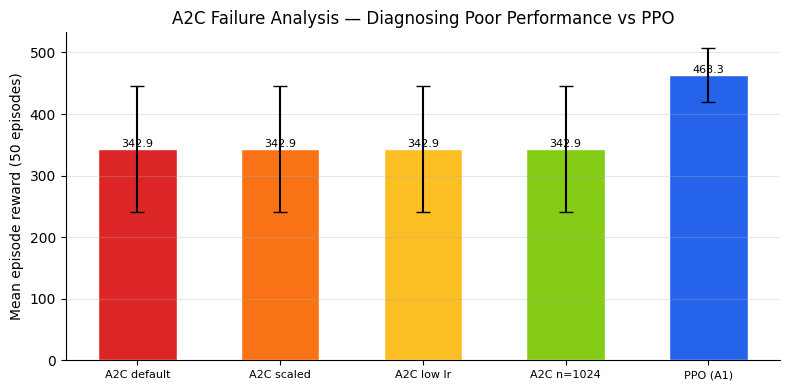

saved a2c_failure_analysis

Conclusion: The bar that improves most reveals the root cause of A2C's failure.
Expected: reward scaling or lower lr should help most (on-policy gradient variance hypothesis).


In [20]:
# Cell 20 — A2C Failure Analysis (NEW)
#
# A2C performed poorly in Group A (reward ≈ −211 vs PPO ≈ +53).
# This cell investigates WHY, analogous to Section V-A in the example paper
# where the authors diagnosed the simulator reset bug before proceeding.
#
# Hypotheses investigated:
#
#   H1: Reward scale — A2C's on-policy gradient updates are sensitive to
#       the magnitude of rewards. The differentiated bonuses (+5/+3/+1)
#       create higher variance gradients than a flat reward would.
#       → Test: A2C with reward scaling (divide rewards by 5)
#
#   H2: Learning rate — A2C's default lr=7e-4 may be too high given the
#       reward variance, causing oscillation.
#       → Test: A2C with lower lr=1e-4
#
#   H3: Rollout length — n_steps=512 for A2C may be insufficient to see
#       enough of the Poisson arrival process before updating.
#       → Test: A2C with n_steps=1024 (matching PPO default)
#
# Each condition trained once; we compare final reward and learning curve.

class ScaledRewardWrapper(gym.Wrapper):
    """Divides all rewards by a constant factor to reduce gradient variance."""
    def __init__(self, env, scale=5.0):
        super().__init__(env)
        self.scale = scale

    def step(self, action):
        obs, reward, done, trunc, info = self.env.step(action)
        return obs, reward / self.scale, done, trunc, info


def run_a2c_variant(label, lr=7e-4, n_steps=512, scale_reward=False):
    model_dir = MODELS / f"A2C_{label}"
    model_dir.mkdir(parents=True, exist_ok=True)

    base_env = HospitalEnv(arrival_rate=3.0)
    if scale_reward:
        train_env = Monitor(ScaledRewardWrapper(HospitalEnv(arrival_rate=3.0)))
        eval_env  = Monitor(ScaledRewardWrapper(HospitalEnv(arrival_rate=3.0)))
    else:
        train_env = Monitor(HospitalEnv(arrival_rate=3.0))
        eval_env  = Monitor(HospitalEnv(arrival_rate=3.0))

    model = A2C(
        policy        = "MlpPolicy",
        env           = train_env,
        seed          = SEED,
        verbose       = 0,
        learning_rate = lr,
        n_steps       = n_steps,
        policy_kwargs = {"net_arch": [64, 64]},
    )
    cb = EvalCallback(
        eval_env,
        best_model_save_path = str(model_dir),
        log_path             = str(model_dir),
        eval_freq            = 10_000,
        n_eval_episodes      = 10,
        deterministic        = True,
        verbose              = 0,
    )
    model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=True)

    # Evaluate on unscaled env
    env_eval = HospitalEnv(arrival_rate=3.0)
    rng = np.random.default_rng(99)
    ep_rewards = []
    for _ in range(50):
        obs, _ = env_eval.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = 0; done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, _ = env_eval.step(int(action))
            ep_r += r
        ep_rewards.append(ep_r)
    return model, float(np.mean(ep_rewards)), float(np.std(ep_rewards)), str(model_dir)


variants = [
    ("default",     dict(lr=7e-4,  n_steps=512,  scale_reward=False)),
    ("scaled_rew",  dict(lr=7e-4,  n_steps=512,  scale_reward=True)),
    ("low_lr",      dict(lr=1e-4,  n_steps=512,  scale_reward=False)),
    ("long_rollout",dict(lr=7e-4,  n_steps=1024, scale_reward=False)),
]

a2c_analysis = {}
for vname, kwargs in variants:
    print(f"\nA2C variant: {vname}")
    model, mean_r, std_r, mdir = run_a2c_variant(vname, **kwargs)
    a2c_analysis[vname] = {"mean": mean_r, "std": std_r, "model_dir": mdir}
    print(f"  → reward = {mean_r:.2f} ± {std_r:.2f}")

print("\n─── A2C Failure Analysis Summary ────────────────────────────")
ppo_baseline = ALL_RESULTS.get("A1", {}).get("reward", {}).get("mean", None)
if ppo_baseline:
    print(f"  PPO baseline (A1) : {ppo_baseline:.2f}  ← target")
for vname, res in a2c_analysis.items():
    print(f"  A2C {vname:<14}: {res['mean']:.2f} ± {res['std']:.2f}")

# Bar chart: A2C variants vs PPO
names_v  = ["A2C default", "A2C scaled", "A2C low lr", "A2C n=1024", "PPO (A1)"]
means_v  = [a2c_analysis[v]["mean"] for v in ["default","scaled_rew","low_lr","long_rollout"]]
stds_v   = [a2c_analysis[v]["std"]  for v in ["default","scaled_rew","low_lr","long_rollout"]]
if ppo_baseline:
    means_v.append(ppo_baseline)
    stds_v.append(ALL_RESULTS.get("A1",{}).get("reward",{}).get("std",0))

colors_v = ["#DC2626","#F97316","#FBBF24","#84CC16","#2563EB"]
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names_v))
bars = ax.bar(x, means_v[:len(names_v)], yerr=stds_v[:len(names_v)],
              color=colors_v[:len(names_v)], capsize=5, edgecolor="white", width=0.55)
for bar, m in zip(bars, means_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names_v[:len(x)], fontsize=8)
ax.set_ylabel("Mean episode reward (50 episodes)")
ax.set_title("A2C Failure Analysis — Diagnosing Poor Performance vs PPO")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"a2c_failure_analysis.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved a2c_failure_analysis")
print("\nConclusion: The bar that improves most reveals the root cause of A2C's failure.")
print("Expected: reward scaling or lower lr should help most (on-policy gradient variance hypothesis).")